In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_orig=pd.read_csv('AppML_ZTF_table.csv',index_col=0)

In [3]:
# remove nonsensical columns
# everything with jd makes no sense on its own - but relative timings do
# coordinates are probably not good either? tho galactic ones might be ok?
cols_to_drop=['objectId', 'decmean', 'decstd', 'ramean', 'rastd','tns_name','tns_type','host_name','dmdt_r_2','ncandgp_7', 'ncandgp_14','dmdt_g_2','htm16','ssnamenr','jdmax','jdmin','jd_g_minus_r','jdgmax','htm16']

# make new features based on combinations of previous features

# duration of light curve
data_orig['duration']=data_orig['jdmax']-data_orig['jdmin']

# difference in peak g and r mag 
data_orig['g_minus_r_max']=data_orig['maggmax']-data_orig['magrmax']
# difference in mean g and r mag
data_orig['g_minus_r_mean']=data_orig['maggmean']-data_orig['magrmean']
data=data_orig.drop(columns=cols_to_drop)
data


,glatmean,glonmean,gmag,dmdt_g,mag_g02,mag_g08,mag_g28,maggmax,maggmean,maggmin,...,dmdt_g_err,dmdt_r_err,z,classification,classificationReliability,distance,separationArcsec,duration,g_minus_r_max,g_minus_r_mean
0,-53.520976,71.836837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.090180,NaN,AGN,1.0,4848.470,0.123,13.982604,NaN,NaN
1,2.579207,231.011386,19.1466,0.009646,19.1494,19.1740,19.1937,19.2051,19.1758,19.1466,...,0.060346,0.043590,NaN,VS,1.0,0.000,0.052,24.988357,-0.1948,0.8060
2,10.407024,165.731135,16.1951,0.039408,16.2240,16.2223,16.1099,16.2683,16.0712,15.9342,...,0.035496,0.035092,NaN,AGN,1.0,89.111,0.130,26.042535,0.5704,0.5677
3,-35.242562,213.676050,19.2207,-0.104339,19.2206,19.0303,18.1721,19.2207,17.6862,17.1446,...,0.007967,0.231327,0.039,NT,1.0,170.768,0.309,27.023750,0.5509,-0.2066
4,-5.830538,209.535243,15.9266,1.091870,16.9390,18.5648,19.2642,20.0026,19.0791,15.9266,...,0.051060,0.043820,NaN,VS,1.0,0.000,0.164,28.000995,-0.1726,0.3781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16333,45.179705,234.125040,19.3177,NaN,19.3177,19.3177,19.3177,19.3177,19.3177,19.3177,...,NaN,0.129790,NaN,NT,1.0,442.711,1.484,12.008113,-0.2865,0.0911
16334,47.456474,232.104407,19.2806,NaN,19.2806,19.2806,19.2806,19.2806,19.2806,19.2806,...,NaN,0.131565,NaN,SN,2.0,444.528,6.756,10.076563,-0.3316,-0.0402
16335,-4.446613,44.499667,19.5741,-0.962985,18.8469,17.7216,16.5062,19.5741,16.7950,15.1485,...,0.075493,0.028401,NaN,SN,2.0,0.000,7.025,29.994780,2.1955,-0.0155
16336,32.862867,145.160817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.063472,NaN,SN,2.0,0.000,2.171,15.129352,NaN,NaN


In [4]:
# clustering 
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

In [6]:
from sklearn.cluster import KMeans

# Remove non-numeric / metadata columns
X = data.drop(columns=["classification", "classificationReliability"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means
kmeans = KMeans(
    n_clusters=5,      # choose a value to start with
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to dataframe
data["cluster"] = clusters

print(data["cluster"].value_counts().sort_index())

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [7]:
# Remove non-numeric / metadata columns
X = data.drop(columns=["classification", "classificationReliability"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Missing values per column
missing = X.isna().sum().sort_values(ascending=False)

# Percentage missing
missing_pct = 100 * X.isna().mean()

print(pd.DataFrame({
    "missing": missing,
    "pct": missing_pct
}).sort_values("pct", ascending=False))

                  missing        pct
z                   11207  68.594687
distance             3381  20.694087
dmdt_g_err           3276  20.051414
sgscore1             2629  16.091321
dmdt_r_err           2621  16.042355
sgmag1               1321   8.085445
srmag1               1321   8.085445
distpsnr1            1321   8.085445
dmdt_g               1084   6.634839
g_minus_r            1023   6.261476
g_minus_r_mean        913   5.588199
g_minus_r_max         913   5.588199
maggmax               839   5.135267
gmag                  839   5.135267
maggmin               839   5.135267
mag_g02               839   5.135267
mag_g08               839   5.135267
mag_g28               839   5.135267
maggmean              839   5.135267
dmdt_r                287   1.756641
separationArcsec      272   1.664830
rmag                   74   0.452932
magrmean               74   0.452932
magrmin                74   0.452932
mag_r08                74   0.452932
magrmax                74   0.452932
m

In [8]:
row_missing_pct = X.isna().mean(axis=1)

print(row_missing_pct.describe())

count    16338.000000
mean         0.068469
std          0.090653
min          0.000000
25%          0.029412
50%          0.029412
75%          0.088235
max          0.558824
dtype: float64


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = data.drop(columns=["classification", "classificationReliability"])

# Missingness indicators
X_missing = X.isna().astype(int).add_suffix("_missing")

# Median imputation
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Combine
X_combined = pd.concat([X_imputed, X_missing], axis=1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

scores = iso.fit_predict(X_scaled)

data["anomaly"] = scores
data_orig['anomaly']=scores

In [11]:
anoms=data_orig[data_orig.anomaly==-1]
anoms.tns_type.unique()

array(['SN IIb', 'SN Ia', nan, 'CV', 'SN II', 'SN Ia-91bg-like', 'TDE',
       'SLSN-I', 'SN Ib', 'SN Ic', 'Varstar'], dtype=object)

In [12]:
anoms.sort_values(by='tns_type',ascending=False)[:40]

,objectId,decmean,decstd,ramean,rastd,glatmean,glonmean,jdgmax,gmag,dmdt_g,...,classificationReliability,distance,separationArcsec,tns_name,tns_type,host_name,duration,g_minus_r_max,g_minus_r_mean,anomaly
16326,ZTF19abqstxq,55.550301,0.074944,296.520644,0.096837,14.898649,88.265270,2.458748e+06,15.6705,22.012400,...,2.0,NaN,4.080,2019nzq,Varstar,NaN,29.871343,-0.1713,-0.1410,-1
8389,ZTF18aabkvpi,15.327406,0.081431,175.039219,0.088162,69.665961,244.789704,2.460089e+06,19.2482,-444.225000,...,1.0,47.800,0.490,2018meh,TDE,NaN,29.979398,NaN,NaN,-1
8390,ZTF18aabkvpi,15.327406,0.081431,175.039219,0.088162,69.665961,244.789704,2.460089e+06,19.2482,-444.225000,...,1.0,47.800,0.490,2023clx,TDE,NaN,29.979398,NaN,NaN,-1
14280,ZTF24aaxjjmx,19.066238,0.067484,79.157957,0.066795,-10.904505,184.735646,NaN,NaN,NaN,...,2.0,77.260,3.753,2024qfh,SN Ic,NaN,3.004167,NaN,NaN,-1
13125,ZTF21abrqrsz,39.764961,0.077153,103.895288,0.062440,17.699949,176.710439,NaN,NaN,NaN,...,2.0,73.070,9.630,2021vnw,SN Ib,NaN,14.986667,NaN,NaN,-1
7704,ZTF22aahgxdt,-3.607085,0.093809,145.700950,0.146678,35.119282,239.468279,2.459711e+06,15.7177,-0.052805,...,NaN,NaN,NaN,2022ihz,SN Ia-91bg-like,NaN,26.031632,-3.2131,-0.0979,-1
10371,ZTF23aadrudf,47.193534,0.075286,199.623402,0.096533,69.243181,109.880433,2.460077e+06,20.2890,-0.057655,...,2.0,260.140,4.010,2023ees,SN Ia,NaN,25.916898,NaN,NaN,-1
6437,ZTF24aahdfsy,33.466289,0.083884,208.049600,0.116613,75.454472,62.435182,2.460424e+06,19.0204,0.027423,...,2.0,0.000,4.109,2024eno,SN Ia,NaN,26.936366,NaN,NaN,-1
6472,ZTF24aaoodsh,21.576802,0.041236,198.480394,0.048578,82.449874,346.816259,2.460490e+06,19.1141,-0.023637,...,2.0,203.544,2.008,2024jeg,SN Ia,NaN,29.980752,NaN,NaN,-1
7349,ZTF20acduffd,43.464778,0.042802,37.838207,0.044576,-15.774778,141.503302,NaN,NaN,NaN,...,2.0,84.960,7.390,2020uea,SN Ia,NaN,27.888565,NaN,NaN,-1


In [13]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=5.0,
    min_samples=10
)

labels = db.fit_predict(X_scaled)

In [14]:
data_orig['dbscan_label']=labels

In [15]:
data_orig

,objectId,decmean,decstd,ramean,rastd,glatmean,glonmean,jdgmax,gmag,dmdt_g,...,distance,separationArcsec,tns_name,tns_type,host_name,duration,g_minus_r_max,g_minus_r_mean,anomaly,dbscan_label
0,ZTF17aaadqia,-1.967911,0.094116,345.283228,0.090943,-53.520976,71.836837,NaN,NaN,NaN,...,4848.470,0.123,2016ihw,NaN,NaN,13.982604,NaN,NaN,1,0
1,ZTF17aaagsai,-14.797043,0.216230,113.674411,0.319206,2.579207,231.011386,2.461103e+06,19.1466,0.009646,...,0.000,0.052,2020ikh,NaN,NaN,24.988357,-0.1948,0.8060,1,1
2,ZTF17aaaocpq,46.439349,0.081709,88.723341,0.205268,10.407024,165.731135,2.461076e+06,16.1951,0.039408,...,89.111,0.130,2018gsn,NaN,NaN,26.042535,0.5704,0.5677,1,1
3,ZTF17aabbwwl,-15.816685,0.292130,70.939101,0.113950,-35.242562,213.676050,2.461095e+06,19.2207,-0.104339,...,170.768,0.309,2026azr,SN Ia,NaN,27.023750,0.5509,-0.2066,1,1
4,ZTF17aabwdlv,0.351560,0.153380,96.123776,0.162534,-5.830538,209.535243,2.461114e+06,15.9266,1.091870,...,0.000,0.164,2017gik,NaN,NaN,28.000995,-0.1726,0.3781,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16333,ZTF24aaaisai,5.546163,0.244596,151.536476,0.248458,45.179705,234.125040,2.460315e+06,19.3177,NaN,...,442.711,1.484,2024in,NaN,NaN,12.008113,-0.2865,0.0911,1,-1
16334,ZTF24aaaisgd,7.950914,0.214477,152.705362,0.204226,47.456474,232.104407,2.460315e+06,19.2806,NaN,...,444.528,6.756,2024iq,NaN,NaN,10.076563,-0.3316,-0.0402,1,-1
16335,ZTF24aasehlg,8.196964,0.028851,292.171778,0.023382,-4.446613,44.499667,2.460510e+06,19.5741,-0.962985,...,0.000,7.025,2024ljz,NaN,NaN,29.994780,2.1955,-0.0155,1,-1
16336,ZTF24aaaayvk,69.957103,0.243272,124.859481,0.623043,32.862867,145.160817,NaN,NaN,NaN,...,0.000,2.171,2024uh,NaN,NaN,15.129352,NaN,NaN,1,-1


In [16]:
len(data[data_orig['dbscan_label']==-1])

763

In [17]:
from sklearn.cluster import HDBSCAN

db = HDBSCAN(
    min_cluster_size=50,cluster_selection_epsilon=5.0
)

labels = db.fit_predict(X_scaled)
data_orig['hdbscan_label']=labels
len(data[data_orig['hdbscan_label']==-1])

1008

In [18]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

/opt/anaconda3/envs/app-ml-2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


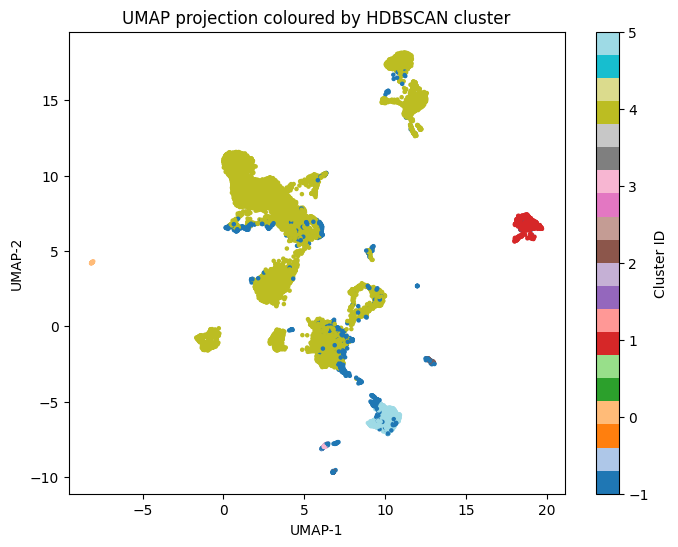

In [19]:
import hdbscan
import matplotlib.pyplot as plt

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    cluster_selection_epsilon=5.0
)

labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=labels,
    cmap="tab20",
    s=5
)

plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP projection coloured by HDBSCAN cluster")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [20]:
len(labels[labels==-1])

1021

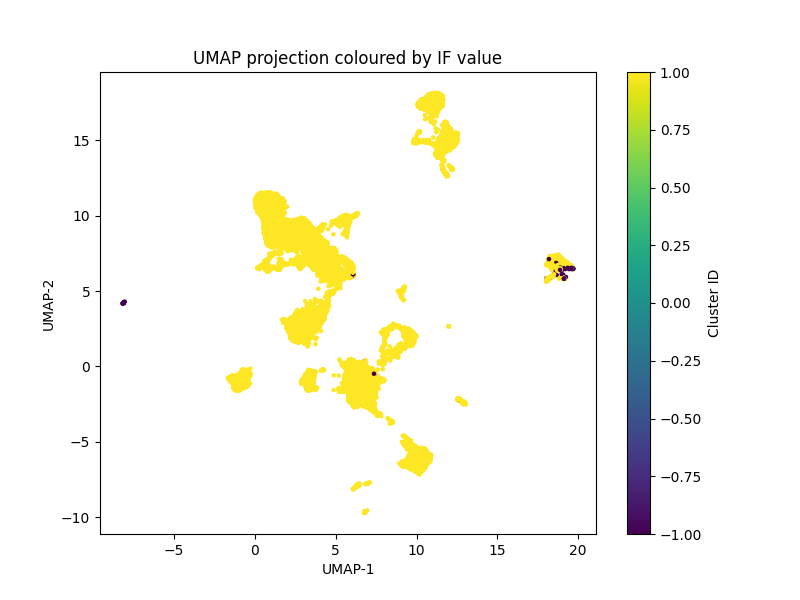

In [21]:
%matplotlib ipympl



plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=data_orig['anomaly'],
    s=5
)

plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP projection coloured by IF value")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

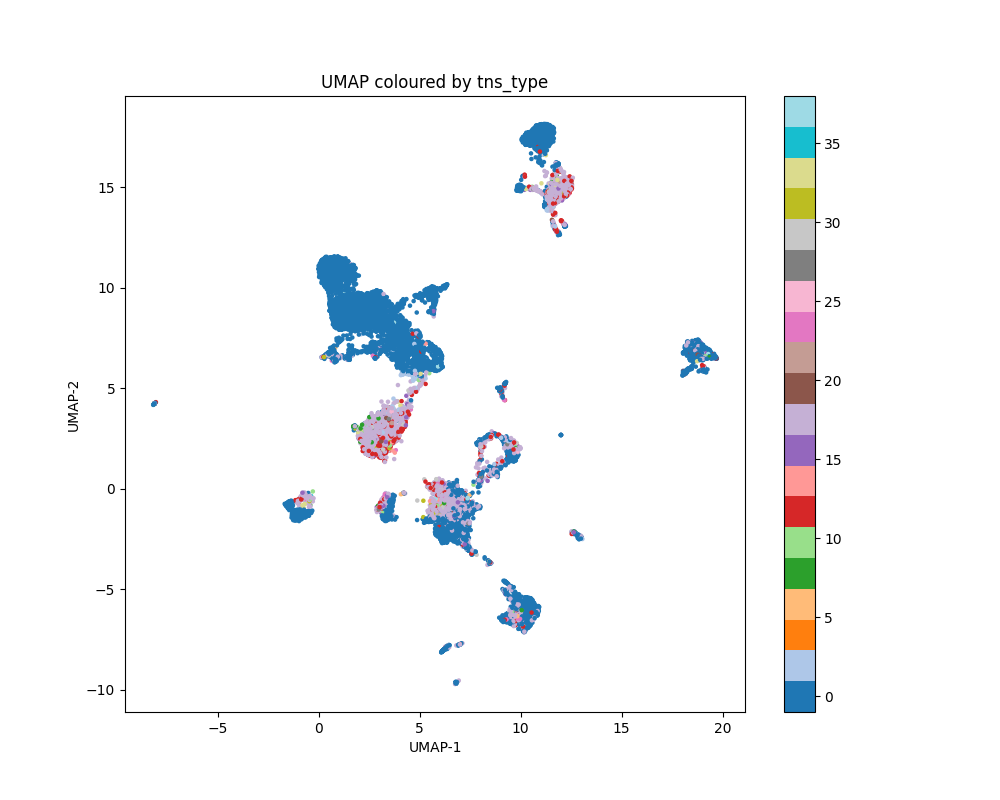

In [31]:
# Convert strings to integer codes
categories = pd.Categorical(data_orig["tns_type"])

codes = categories.codes          # 0, 1, 2, ...
labels = categories.categories    # actual names

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=codes,
    cmap="tab20",
    s=5
)

cbar = plt.colorbar(scatter)
#cbar.set_ticks(range(len(labels)))
#cbar.set_ticklabels(labels)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP coloured by tns_type")
plt.show()

In [23]:
print(data_orig["tns_type"].value_counts())

tns_type
SN Ia                3658
SN II                 606
CV                    125
SN Ia-91T-like        114
SN IIn                109
SN Ic                  72
SN Ib                  60
SLSN-I                 50
SN IIb                 48
TDE                    46
SN Ic-BL               38
AGN                    33
SN IIP                 30
SLSN-II                22
SN Ibn                 22
SN Ia-pec              21
SN Ia-91bg-like        21
Varstar                16
Nova                   15
SN                     15
SN Iax[02cx-like]      12
SN Ib/c                10
SN I                   10
SN Ia-CSM               7
SN Ia-SC                5
SN Ib-pec               5
SN II-pec               4
TDE-featureless         4
Galaxy                  4
TDE-H-He                3
TDE-He                  2
LBV                     2
SN Ibn/Icn              2
QSO                     2
NA/Unknown              1
LRN                     1
SN Icn                  1
SN Ic-pec               1
SN 

In [24]:
print(len(data_orig["tns_type"].unique()))

40


/var/folders/z1/c7w4xcjn3c7479pfs85459zc0000z9/T/ipykernel_77071/491302551.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo").copy()


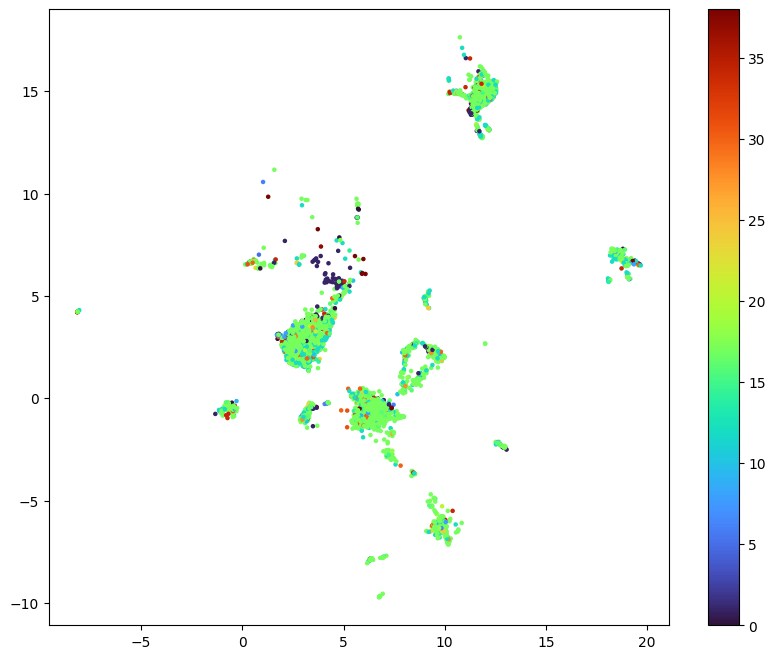

In [25]:

categories = pd.Categorical(data_orig["tns_type"])

codes = categories.codes.astype(float)

# Replace NaNs (-1) with np.nan
codes[codes == -1] = np.nan

cmap = plt.cm.get_cmap("turbo").copy()
cmap.set_bad("lightgray")

plt.figure(figsize=(10,8))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=codes,
    cmap=cmap,
    s=5
)

plt.colorbar()
plt.show()

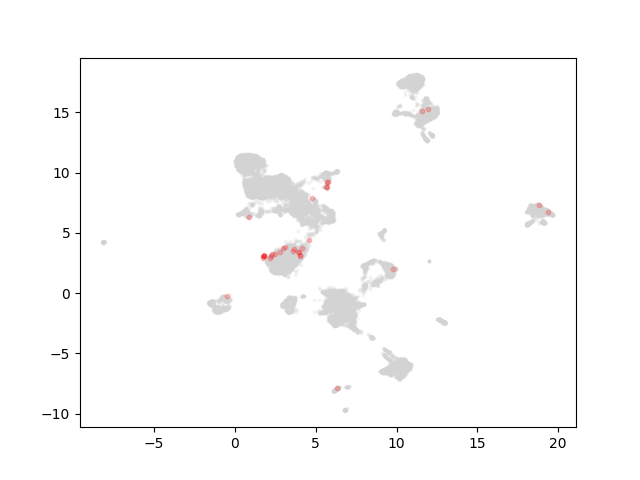

In [36]:
mask = data_orig["tns_type"] == "AGN"
plt.figure()
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    color="lightgray",
    s=3,
    alpha=0.2
)

plt.scatter(
    embedding[mask,0],
    embedding[mask,1],
    color="red",
    s=10,alpha=.2
)
plt.show()

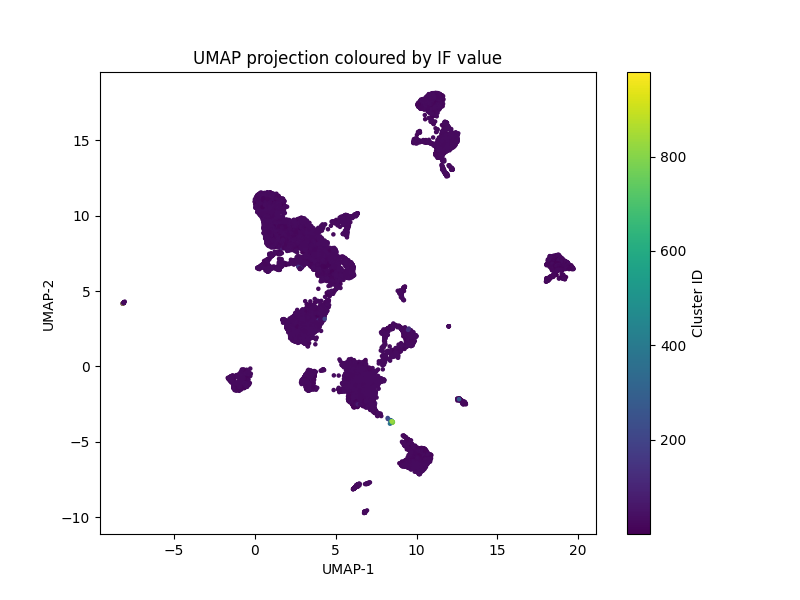

In [32]:
%matplotlib ipympl



plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=data_orig['duration'],
    s=5
)

plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP projection coloured by IF value")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()